# Каталог и retrieval: EDA актуального пайплайна

Дата актуализации: 22.09.2026. Этот notebook описывает каталог, который использует
production-пайплайн: RT-DETR → SigLIP 2 + PCA-whitening → FAISS, OCR PaddleOCR,
XFeat/RANSAC и CatBoost. Исторические DINOv2 и старый label detector не используются
для текущего индекса.

Каталог — это поисковая база, не набор классов: новый slug добавляется в индекс, а
нейросети не переобучаются. Поэтому особое внимание уделено дубликатам картинок, sibling
линейкам и полноте эталонов.

In [1]:
from pathlib import Path
import json, os, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
plt.rcParams['figure.dpi'] = 110

def read_jsonl(relative):
    path = ROOT / relative
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line] if path.exists() else []

def image_path(slug):
    return ROOT / 'data/catalog/originals' / f'{slug}.png'


## 1. Полнота и состав каталога

,значение
карточек,2103
с доступным эталоном,2103
без эталона,0
опубликовано на сайте,2037
виноделен,135


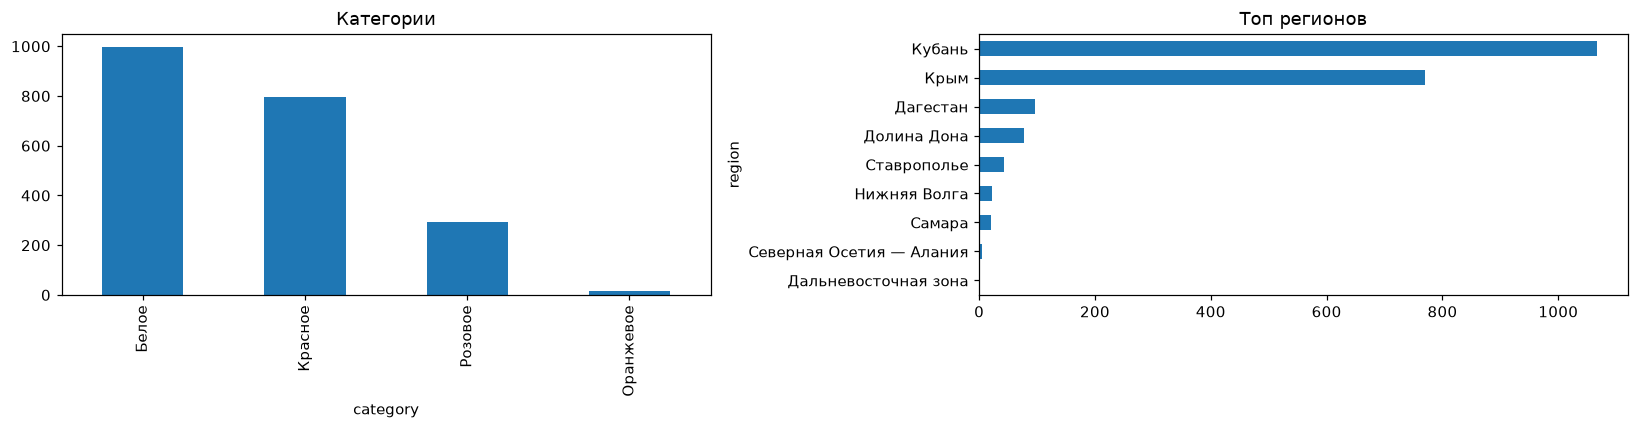

In [2]:
catalog = pd.read_csv(ROOT / 'data/catalog/catalog.csv')
quality = pd.Series({
    'карточек': len(catalog),
    'с доступным эталоном': catalog.source_file.notna().sum(),
    'без эталона': catalog.source_file.isna().sum(),
    'опубликовано на сайте': catalog.on_site.fillna(False).sum(),
    'виноделен': catalog.winery.nunique(),
})
display(quality.rename('значение').to_frame())
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
catalog.category.fillna('Не указано').value_counts().plot.bar(ax=axes[0], title='Категории')
catalog.region.fillna('Не указано').value_counts().head(15).sort_values().plot.barh(
    ax=axes[1], title='Топ регионов')
plt.tight_layout(); plt.show()

### Вывод раздела 1

Каталог достаточно велик для retrieval, а не для надёжной закрытой классификации. Полнота
эталонов — прямой потолок качества: для карточки без картинки visual-ветка не может вернуть
правильный slug, поэтому такие строки должны оставаться в очереди каталожной ревизии.

## 2. Siblings, общие фото и семантические дубликаты

,значение
slug в name+winery sibling-группах,196
sibling-групп,90
slug с shared_photo,26
slug с shared_image (байт-в-байт),55


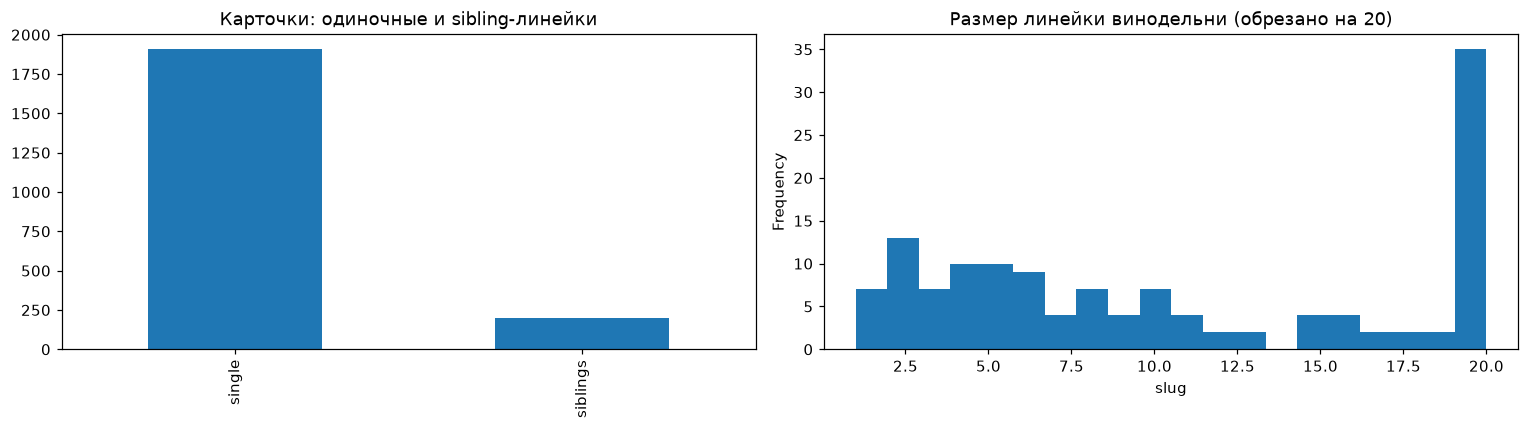

,winery,name,slug,category,shared_image
235,AYA Organic Wine & Vineyards,Evolution Pinot Noir,aya-organic-wine-vineyards-evolution-pinot-noi...,Красное,False
234,AYA Organic Wine & Vineyards,Evolution pinot noir,evolution-pinot-noir,Розовое,False
479,AYA Organic Wine & Vineyards,Purity in Syrah,aya-organic-wine-vineyards-purity-in-syrah-sir...,Красное,False
480,AYA Organic Wine & Vineyards,Purity in Syrah,aya-organic-wine-vineyards-purity-in-syrah-sir...,Розовое,False
888,Alma Valley,Гравити,alma-valley-graviti-pino-blan-beloe-suhoe-135,Белое,False
889,Alma Valley,Гравити,alma-valley-graviti-kaberne-sovinon-krasnoe-su...,Красное,False
1310,Alma Valley,Мерло Резерв,alma-valley-merlo-rezerv-krasnoe-suhoe-15,Красное,False
1311,Alma Valley,Мерло Резерв,alma-valley-merlo-rezerv-krasnoe-suhoe-14,Красное,False
1462,Alma Valley,Пино Нуар,alma-valley-pino-nuar-krasnoe-suhoe-13,Красное,False
1464,Alma Valley,Пино Нуар,alma-valley-pino-nuar-beloe-ekstra-bryut-115,Белое,False


In [3]:
catalog['name_norm'] = (catalog.name.fillna('').str.lower()
                        .str.replace(r'[, ]*20[0-3][0-9]', '', regex=True)
                        .str.replace(r'\s+', ' ', regex=True).str.strip())
family_size = catalog.groupby(['winery', 'name_norm']).slug.transform('size')
siblings = catalog[family_size > 1].copy()
duplicate_summary = pd.Series({
    'slug в name+winery sibling-группах': len(siblings),
    'sibling-групп': siblings.groupby(['winery', 'name_norm']).ngroups,
    'slug с shared_photo': catalog.shared_photo.fillna(False).sum(),
    'slug с shared_image (байт-в-байт)': catalog.shared_image.fillna(False).sum(),
})
display(duplicate_summary.rename('значение').to_frame())
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pd.Series({'single': (family_size == 1).sum(), 'siblings': (family_size > 1).sum()}).plot.bar(
    ax=axes[0], title='Карточки: одиночные и sibling-линейки')
catalog.groupby('winery').size().clip(upper=20).plot.hist(bins=20, ax=axes[1],
    title='Размер линейки винодельни (обрезано на 20)')
axes[1].set_xlabel('slug'); plt.tight_layout(); plt.show()
display(siblings[['winery', 'name', 'slug', 'category', 'shared_image']]
        .sort_values(['winery', 'name']).head(30))

G:\Projects\python\rshb_my_wine_app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


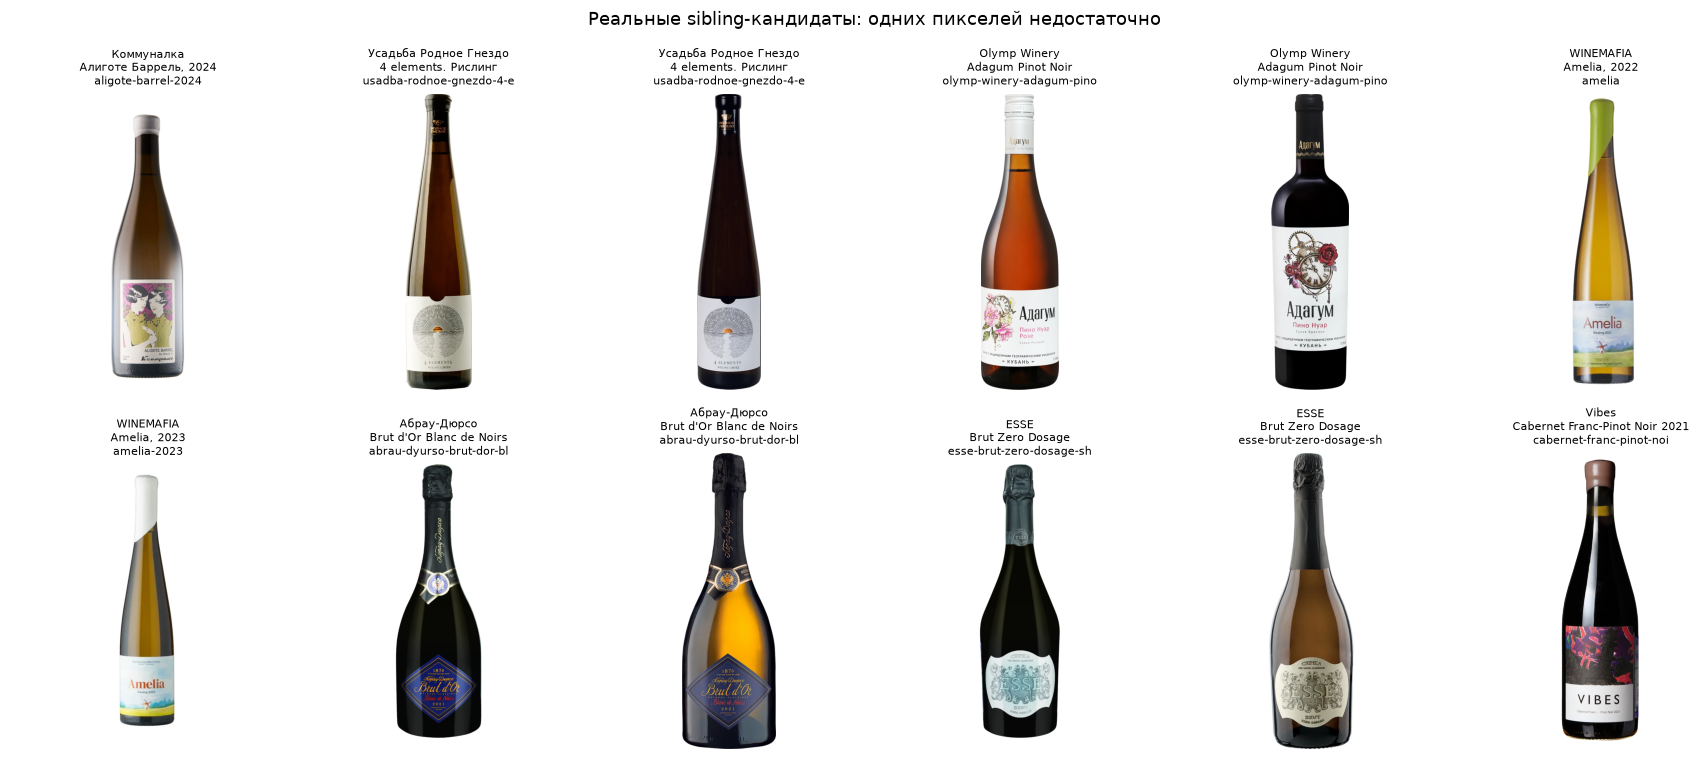

In [4]:
from wine_scanner.embed import load_image

examples = siblings[siblings.slug.map(lambda x: image_path(x).exists())].groupby('winery').head(2).head(12)
if len(examples):
    fig, axes = plt.subplots(2, 6, figsize=(16, 7)); axes = axes.flat
    for axis, row in zip(axes, examples.itertuples()):
        axis.imshow(load_image(image_path(row.slug))); axis.axis('off')
        axis.set_title(f'{row.winery}\n{row.name}\n{row.slug[:24]}', fontsize=7)
    for axis in axes[len(examples):]: axis.axis('off')
    plt.suptitle('Реальные sibling-кандидаты: одних пикселей недостаточно')
    plt.tight_layout(); plt.show()

### Парный аудит sibling-кандидатов

Ниже показаны именно две карточки одной пары, а не случайные бутылки общего производителя.
Причина объединения подписана: shared image означает байт-в-байт одинаковый эталон, а
«одинаковое имя + винодельня» — только гипотеза визуальной похожести, которую проверяем
глазами по двум этикеткам.

,причина пары,slug слева,название слева,slug справа,название справа,винодельня
0,shared_image: байт-в-байт один эталон,villa-urkusta-kaberne-sovinon-klassik-krasnoe-...,Каберне совиньон Классик,villa-urkusta-kaberne-sovinon-klassik-krasnoe-...,Каберне совиньон Классик,Вилла Уркуста
1,shared_image: байт-в-байт один эталон,agrolayn-heritage-dg-skin-contact-red-saperavi...,Heritage Dg Skin Contact Red,agrolayn-heritage-dg-skin-contact-rkatsiteli-r...,Heritage DG Skin contact Rkatsiteli,Агролайн
2,shared_image: байт-в-байт один эталон,oxana-istratova-wine-rkatsiteli-2023-oranzhevo...,Ркацители 2023,oxana-istratova-wine-rkatsiteli-2024-oranzhevo...,Ркацители 2024,Oxana Istratova Wine
3,shared_image: байт-в-байт один эталон,esse-demi-sec-muscat-nectar-muskat-belyy-beloe...,Demi-Sec Muscat Nectar,esse-muskat-muskat-belyy-beloe-ekstra-bryut-115,Muskat,ESSE
4,shared_image: байт-в-байт один эталон,oxana-istratova-wine-vione-2023-oranzhevoe-suh...,Вионье 2023,oxana-istratova-wine-vione-2024-oranzhevoe-suh...,Вионье 2024,Oxana Istratova Wine
5,shared_image: байт-в-байт один эталон,kokur-suhoe-2025,"Кокур Сухое, 2025",kokur-2025,"Кокур, 2025",Винодельня Братьев Мельниковых
6,shared_image: байт-в-байт один эталон,belmas-winery-pn-pino-nuar-krasnoe-suhoe-135,Pn,belmas-winery-vi-vione-beloe-suhoe-122,Vi,Belmas Winery
7,shared_image: байт-в-байт один эталон,agora-yachting-cabernet-sauvignon,Agora Yachting Cabernet Sauvignon,agora-yachting-sauvignon,Agora Yachting Sauvignon,AGORA WINERY


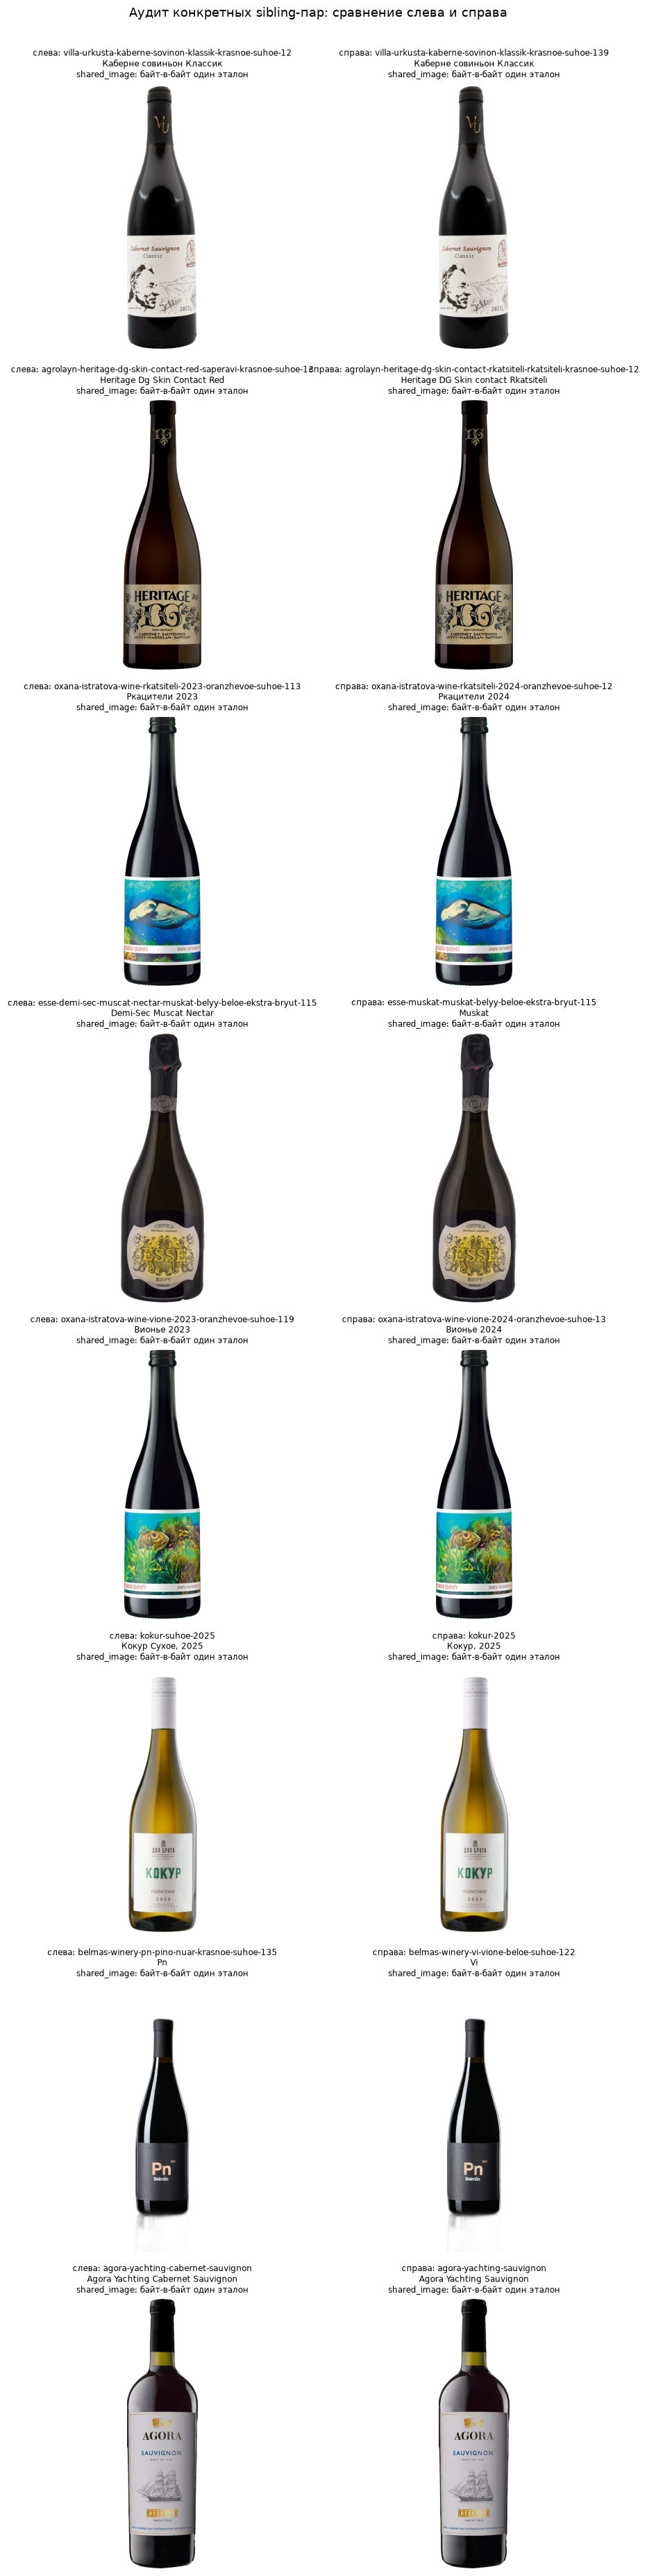

In [5]:
# Строим именно ПАРЫ. Сначала — идентичные по image_md5, затем
# разные файлы с одинаковым названием внутри винодельни.
pairs = []
used = set()
with_image = catalog[catalog.slug.map(lambda slug: image_path(slug).exists())].copy()
for _, group in with_image[with_image.shared_image.fillna(False)].groupby('image_md5'):
    if len(group) >= 2:
        left, right = group.iloc[0], group.iloc[1]
        key = tuple(sorted((left.slug, right.slug)))
        if key not in used:
            used.add(key)
            pairs.append({'reason': 'shared_image: байт-в-байт один эталон',
                          'left': left, 'right': right})

for _, group in siblings.groupby(['winery', 'name_norm']):
    group = group[group.slug.map(lambda slug: image_path(slug).exists())]
    if len(group) < 2 or group.image_md5.nunique(dropna=True) < 2:
        continue
    left, right = group.iloc[0], group.iloc[1]
    key = tuple(sorted((left.slug, right.slug)))
    if key not in used:
        used.add(key)
        pairs.append({'reason': 'одинаковое имя + винодельня, разные файлы',
                      'left': left, 'right': right})

pairs = pairs[:8]
pair_table = pd.DataFrame([{
    'причина пары': pair['reason'],
    'slug слева': pair['left'].slug, 'название слева': pair['left']['name'],
    'slug справа': pair['right'].slug, 'название справа': pair['right']['name'],
    'винодельня': pair['left'].winery,
} for pair in pairs])
display(pair_table)

if pairs:
    fig, axes = plt.subplots(len(pairs), 2, figsize=(10, 4.2 * len(pairs)), squeeze=False)
    for row_axes, pair in zip(axes, pairs):
        for axis, card, side in zip(row_axes, (pair['left'], pair['right']), ('слева', 'справа')):
            axis.imshow(load_image(image_path(card.slug))); axis.axis('off')
            axis.set_title(f"{side}: {card.slug}\n{card['name']}\n{pair['reason']}", fontsize=8)
    plt.suptitle('Аудит конкретных sibling-пар: сравнение слева и справа', y=1.002)
    plt.tight_layout(); plt.show()
else:
    print('Нет пар с двумя доступными эталонами.')

### Вывод раздела 2

Visual nearest-neighbour обычно находит производителя или дизайн семейства, но общая
этикетка не содержит достаточной информации для выбора конкретного slug. Поэтому текущий
пайплайн добавляет OCR, различающие слова, цвет/стиль и sibling guard; совпадение картинки
само по себе не является основанием выдать ответ.

## 3. Качество эталонных изображений

,count,mean,std,min,25%,50%,75%,max
width,2103.0,762.0,798.0,116.0,271.0,336.0,1024.0,6337.0
height,2103.0,1739.0,1359.0,357.0,1000.0,1080.0,2000.0,9506.0


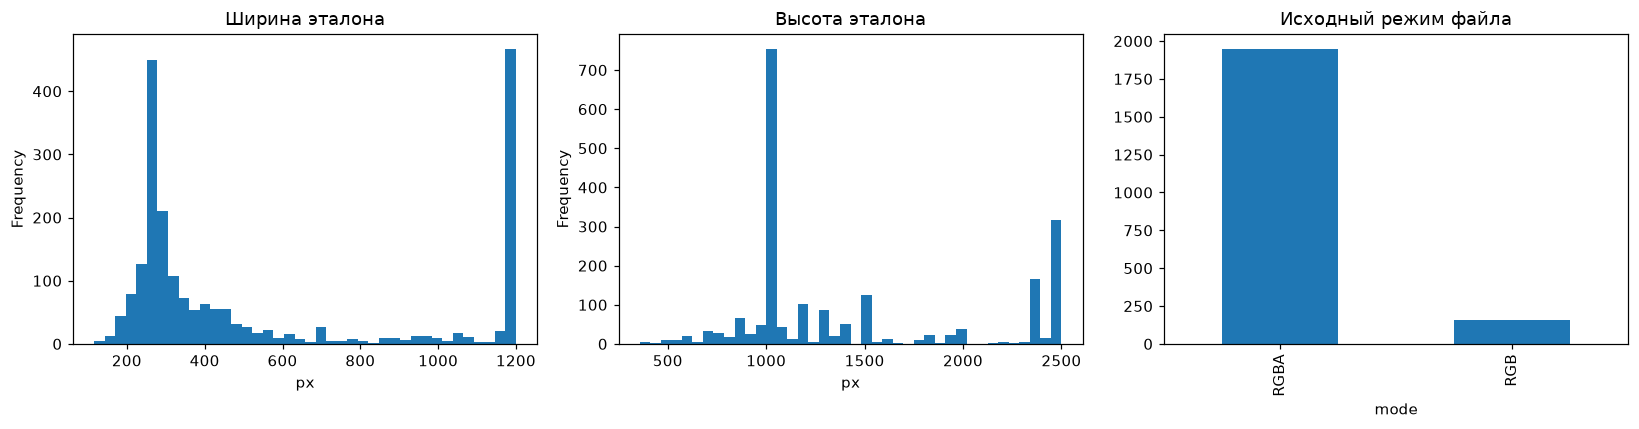

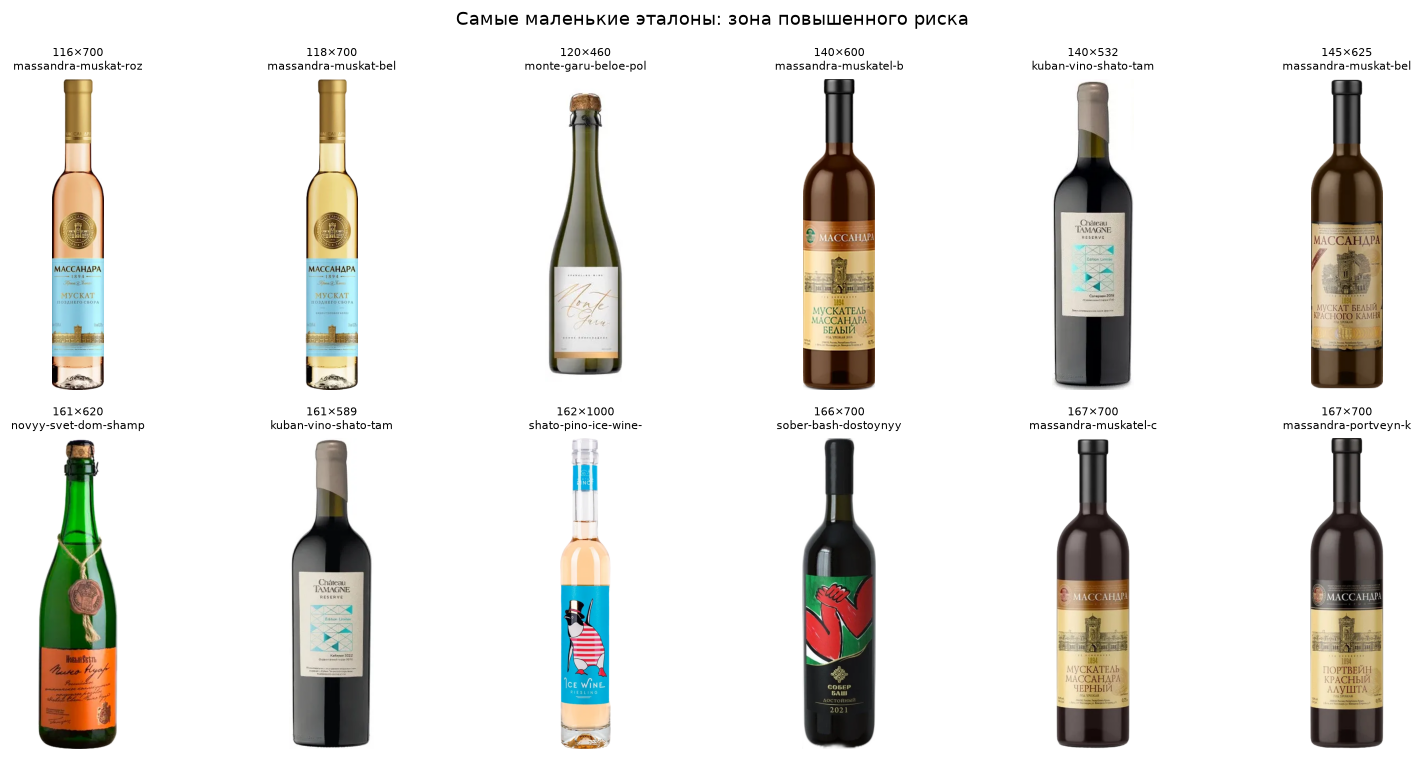

In [6]:
refs = catalog[catalog.slug.map(lambda x: image_path(x).exists())].copy()
display(refs[['width', 'height']].describe().round(0).T)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
refs.width.clip(upper=1200).plot.hist(bins=40, ax=axes[0], title='Ширина эталона')
refs.height.clip(upper=2500).plot.hist(bins=40, ax=axes[1], title='Высота эталона')
refs['mode'].fillna('неизвестно').value_counts().plot.bar(ax=axes[2], title='Исходный режим файла')
for axis in axes[:2]: axis.set_xlabel('px')
plt.tight_layout(); plt.show()

small = refs.nsmallest(12, 'width')
fig, axes = plt.subplots(2, 6, figsize=(15, 7)); axes = axes.flat
for axis, row in zip(axes, small.itertuples()):
    axis.imshow(load_image(image_path(row.slug))); axis.axis('off')
    axis.set_title(f'{row.width}×{row.height}\n{row.slug[:20]}', fontsize=7)
plt.suptitle('Самые маленькие эталоны: зона повышенного риска')
plt.tight_layout(); plt.show()

### Вывод раздела 3

Маленькие и неоднородные эталоны ограничивают как OCR, так и visual similarity. RT-DETR и
padding приводят запрос и карточку к единому виду, но не способны восстановить символы,
которых физически нет в исходном эталоне. Приоритет улучшений — сначала заменить слабые
файлы каталога.

## 4. Visual retrieval и ближайшие соседи SigLIP 2

,значение
count,2103.000000
mean,0.892415
std,0.065240
min,0.597475
25%,0.853563
50%,0.902609
75%,0.940570
max,1.000000


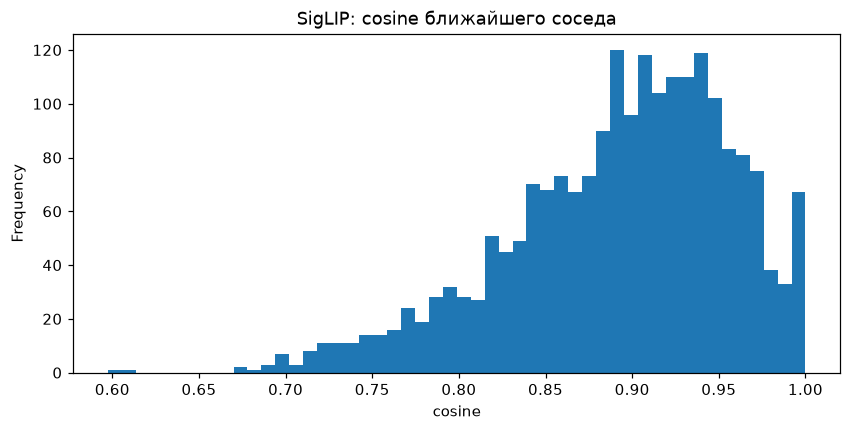

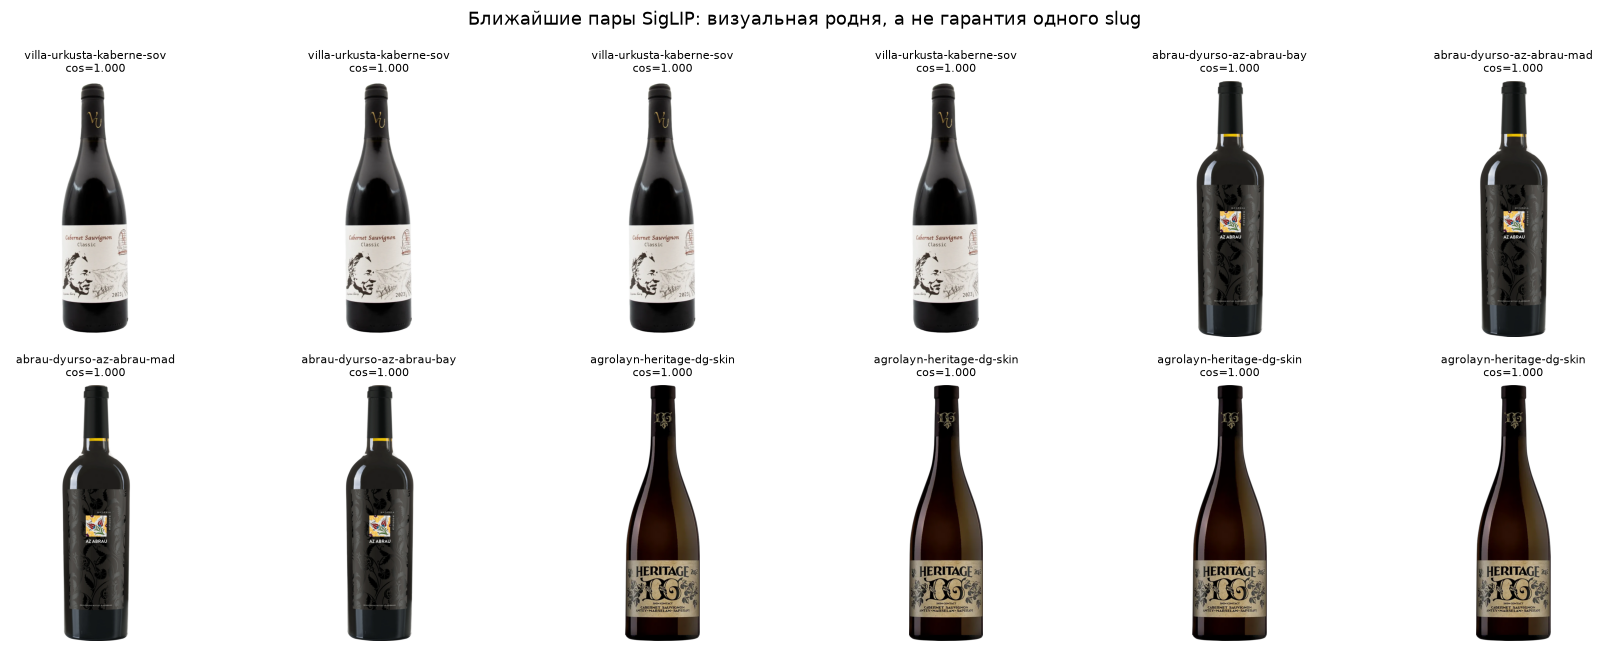

In [7]:
from wine_scanner.index import VectorIndex

index = VectorIndex.load(ROOT / 'models/index_platform_sq_v3')
vectors = index.index.reconstruct_n(0, index.index.ntotal)
ids = np.array(index.item_ids)
similarity = vectors @ vectors.T
np.fill_diagonal(similarity, -1)
nearest_index = similarity.argmax(axis=1)
nearest = pd.DataFrame({'slug': ids, 'nearest_slug': ids[nearest_index],
                        'cosine': similarity.max(axis=1)})
display(nearest.cosine.describe().to_frame('значение'))
nearest.cosine.plot.hist(bins=50, figsize=(9, 4), title='SigLIP: cosine ближайшего соседа')
plt.xlabel('cosine'); plt.show()

top_pairs = nearest.nlargest(6, 'cosine')
fig, axes = plt.subplots(2, 6, figsize=(16, 6)); axes = axes.flat
for pair_number, row in enumerate(top_pairs.itertuples()):
    for offset, slug in enumerate((row.slug, row.nearest_slug)):
        axis = axes[pair_number * 2 + offset]
        if image_path(slug).exists(): axis.imshow(load_image(image_path(slug)))
        axis.axis('off'); axis.set_title(f'{slug[:25]}\ncos={row.cosine:.3f}', fontsize=7)
plt.suptitle('Ближайшие пары SigLIP: визуальная родня, а не гарантия одного slug')
plt.tight_layout(); plt.show()

### Вывод раздела 4

SigLIP 2 повышает recall и быстро сужает поиск с тысяч карточек до кандидатов. Высокий cosine
следует трактовать как сигнал похожести, а не как вероятность правильного ответа: особенно
для показанных близких пар решение принимает CatBoost после OCR и геометрии.

## 5. Данные оценки и защита от утечки

,split,frames,wines,unknown
0,train,344,150,247
1,test / holdout,218,106,114


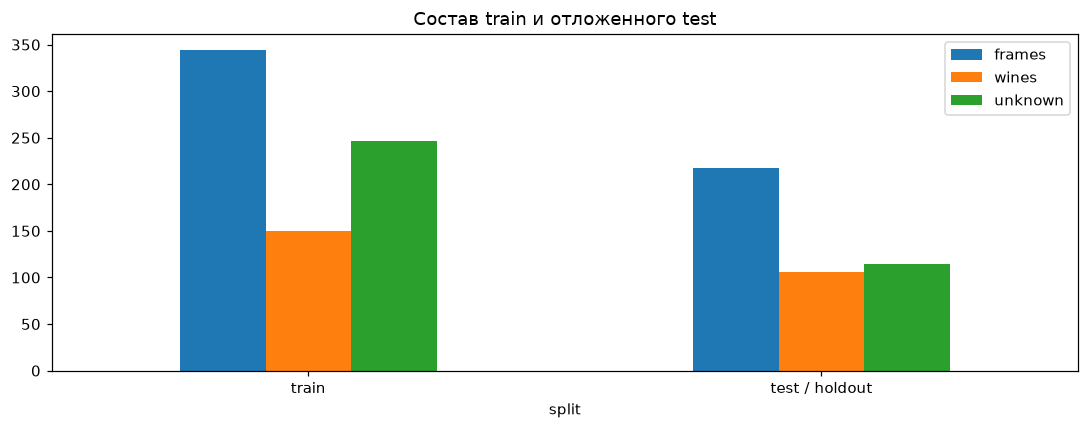

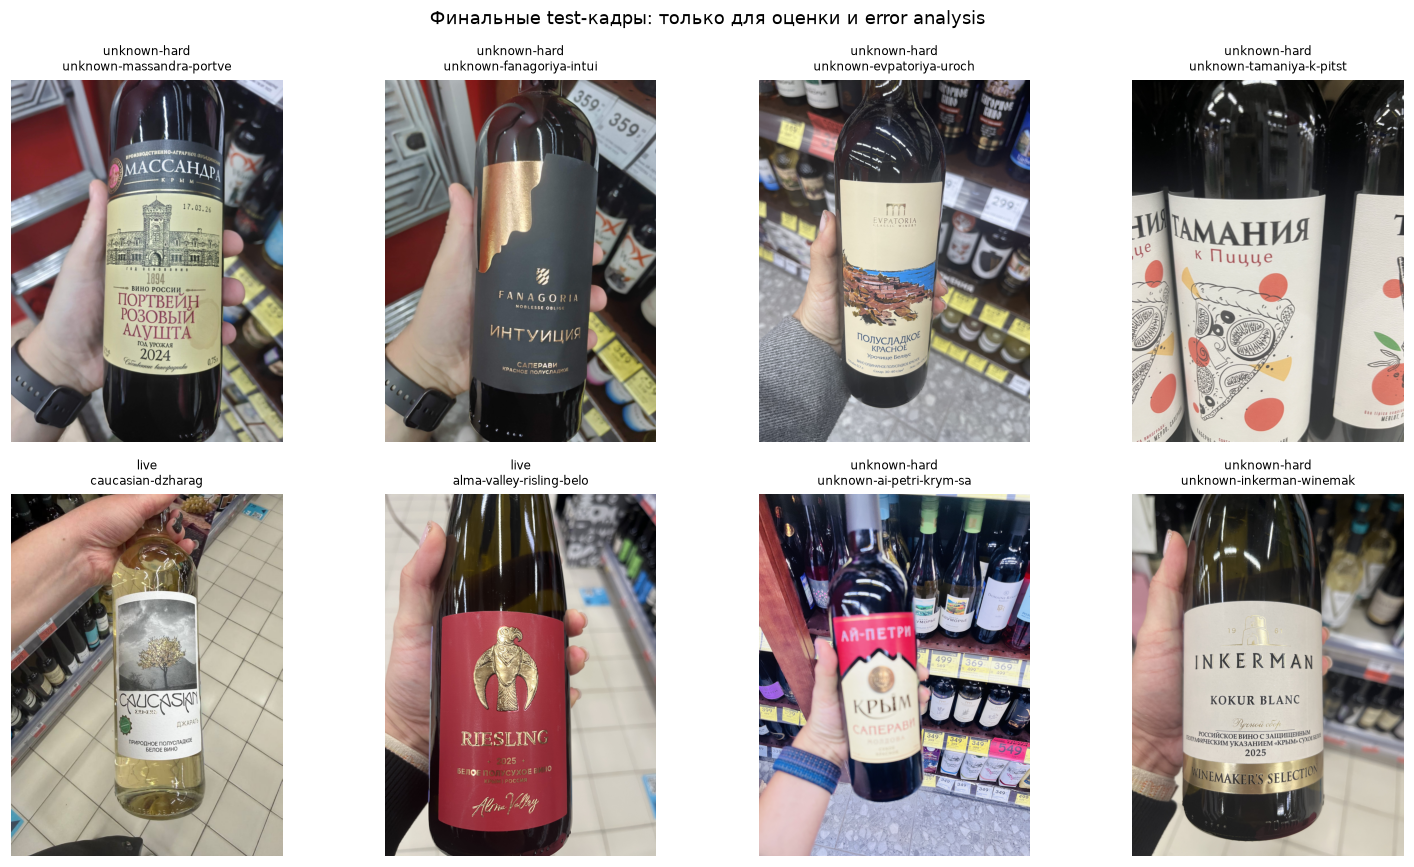

In [8]:
train = pd.read_csv(ROOT / 'data/train/manifest.csv')
test = pd.read_csv(ROOT / 'data/test/manifest.csv')
split = pd.DataFrame([
    {'split': 'train', 'frames': len(train), 'wines': train.wine_id.nunique(),
     'unknown': train.true_slug.isna().sum()},
    {'split': 'test / holdout', 'frames': len(test), 'wines': test.wine_id.nunique(),
     'unknown': test.true_slug.isna().sum()},
])
display(split)
split.set_index('split')[['frames', 'wines', 'unknown']].plot.bar(figsize=(10, 4),
    title='Состав train и отложенного test')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
assert set(train.path).isdisjoint(test.path), 'Файл одновременно в train и test'

sample = test.sample(min(8, len(test)), random_state=2026)
fig, axes = plt.subplots(2, 4, figsize=(14, 8)); axes = axes.flat
for axis, row in zip(axes, sample.itertuples()):
    path = ROOT / row.path
    if path.exists(): axis.imshow(load_image(path))
    axis.axis('off'); axis.set_title(f'{row.group}\n{row.wine_id[:24]}', fontsize=8)
plt.suptitle('Финальные test-кадры: только для оценки и error analysis')
plt.tight_layout(); plt.show()

### Вывод раздела 5

Holdout — заранее отложенный test: на нём запрещены обучение, подбор эпохи, feature selection
и настройка порога. Он нужен, чтобы итоговая метрика отвечала на вопрос о новых фото, а не о
случайно запомненных примерах. Ошибки holdout можно визуализировать и анализировать, но не
превращать в новые параметры без отдельного нового test.

## Итог EDA

Каталог определяет архитектуру: retrieval вместо классификации, текст для sibling-линеек и
отказ для open-world. Самые полезные следующие данные — более качественные эталоны для слабых
slug и новая независимая validation-группа реальных незнакомых вин.